<a href="https://colab.research.google.com/github/twillixa/PPS/blob/main/Main_1_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pulp import (
    LpProblem, LpMinimize, LpVariable, LpInteger,
    lpSum, value, PULP_CBC_CMD
)

##Data loading

In [2]:





REPO_URL = "https://github.com/twillixa/PPS"
CSV_FILENAME = "Demand_data.csv"
RAW_URL = f"https://raw.githubusercontent.com/twillixa/PPS/main/{CSV_FILENAME}"

demand_df = pd.read_csv(RAW_URL)
demand_df.columns = [
    "Day",
    "3235 Movement",
    "Oystersteel Case",
    "Sapphire Crystal",
    "Jubilee Bracelet",
    "Lubricant Oil",
    "Diamond Marker",
    "Gold Crown",
]

component_names = [c for c in demand_df.columns if c != "Day"]

# Per-component summary statistics (daily)
demand_stats = {}
for comp in component_names:
    series = demand_df[comp]
    demand_stats[comp] = {
        "mean_daily": round(series.mean(), 4),
        "std_daily":  round(series.std(ddof=1), 4),
        "min_daily":  int(series.min()),
        "max_daily":  int(series.max()),
        "total":      int(series.sum()),
    }

print(f"Loaded '{CSV_FILENAME}' from {REPO_URL}")
print(f"{len(demand_df)} days, {len(component_names)} components\n")
print(f"  {'Component':<20} {'Mean/day':>9} {'Std/day':>9} {'Min':>5} {'Max':>5} {'Total':>7}")
print(f"  {'-'*58}")
for comp, s in demand_stats.items():
    print(f"  {comp:<20} {s['mean_daily']:>9.2f} {s['std_daily']:>9.2f} "
          f"{s['min_daily']:>5} {s['max_daily']:>5} {s['total']:>7}")

Loaded 'Demand_data.csv' from https://github.com/twillixa/PPS
365 days, 7 components

  Component             Mean/day   Std/day   Min   Max   Total
  ----------------------------------------------------------
  3235 Movement            14.26      3.56     5    25    5205
  Oystersteel Case         15.18      4.28     4    29    5540
  Sapphire Crystal         14.21      3.59     4    25    5187
  Jubilee Bracelet          8.02      0.99     5    12    2926
  Lubricant Oil           150.72     41.18    40   298   55014
  Diamond Marker           47.81      5.09    35    63   17449
  Gold Crown                8.01      3.03     0    17    2922


In [3]:

# ------------------------------------------------------------
# AGGREGATE PLANNING PARAMETERS (Table 1)
# ------------------------------------------------------------

planning_horizon = 12  # months (January to December)

# Workforce & Production
initial_workers = 90          # workers at start of January
production_rate = 10          # watches per worker per month

# Inventory
starting_inventory = 900      # watches (beginning of January)
ending_inventory_target = 1000  # watches (end of December)
holding_cost = 1000           # CHF per watch per month

# Labor Costs
regular_wage = 7000           # CHF per worker per month
hiring_cost = 50000           # CHF per worker hired
layoff_cost = 25000           # CHF per worker laid off

# Overtime
overtime_allowance = 0.20     # up to 20% extra capacity
overtime_cost_multiplier = 2  # 2x regular wage
overtime_months = [3, 5, 9, 12]  # March, May, September, December

# Subcontracting
subcontracting_limit = 300    # watches per month (max)
subcontracting_cost = 15000   # CHF per watch
subcontracting_months = [6, 7, 10, 12]  # June, July, October, December

# Derived: overtime cost per worker per month (when overtime is used)
overtime_cost_per_worker = regular_wage * overtime_cost_multiplier  # CHF

# ------------------------------------------------------------
# FORECASTED MONTHLY DEMAND (Table 2)
# ------------------------------------------------------------

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

demand = {
    "Jan": 900,
    "Feb": 950,
    "Mar": 1200,
    "Apr": 1050,
    "May": 1100,
    "Jun": 1300,
    "Jul": 1250,
    "Aug": 1100,
    "Sep": 1300,
    "Oct": 1450,
    "Nov": 1500,
    "Dec": 1700,
}

demand_list = [demand[m] for m in months]
total_annual_demand = sum(demand_list)  # total watches needed

# ------------------------------------------------------------
# INVENTORY MANAGEMENT PARAMETERS (Table 3)
# ------------------------------------------------------------
# Components for Aurelius SA watches
# Keys: lead_time (days), holding_cost (CHF/unit/month),
#       ordering_cost (CHF), shelf_life (days), supplier

components = {
    "3235 Movement": {
        "lead_time_days": 60,
        "holding_cost_per_unit_month": 1200,  # CHF/unit/month
        "ordering_cost": 9000,                # CHF per order
        "shelf_life_days": 365,
        "supplier": "Supplier",
    },
    "Oystersteel Case": {
        "lead_time_days": 45,
        "holding_cost_per_unit_month": 400,
        "ordering_cost": 7000,
        "shelf_life_days": 505,
        "supplier": "Internal",
    },
    "Sapphire Crystal": {
        "lead_time_days": 30,
        "holding_cost_per_unit_month": 200,
        "ordering_cost": 4000,
        "shelf_life_days": 365,
        "supplier": "Internal",
    },
    "Jubilee Bracelet": {
        "lead_time_days": 35,
        "holding_cost_per_unit_month": 220,
        "ordering_cost": 3500,
        "shelf_life_days": 1460,
        "supplier": "Internal",
    },
    "Lubricant Oil": {
        "lead_time_days": 14,
        "holding_cost_per_unit_month": 50,
        "ordering_cost": 1000,
        "shelf_life_days": 730,
        "supplier": "Supplier DE",
    },
    "Diamond Marker": {
        "lead_time_days": 21,
        "holding_cost_per_unit_month": 900,
        "ordering_cost": 6000,
        "shelf_life_days": 1825,
        "supplier": "Supplier CH",
    },
    "Gold Crown": {
        "lead_time_days": 40,
        "holding_cost_per_unit_month": 350,
        "ordering_cost": 5000,
        "shelf_life_days": 730,
        "supplier": "Supplier CH",
    },
}

# ------------------------------------------------------------
# SUMMARY PRINTOUT
# ------------------------------------------------------------

if __name__ == "__main__":
    print("=" * 55)
    print("AURELIUS SA — PROJECT PART 1 DATA SUMMARY")
    print("=" * 55)

    print("\n--- Aggregate Planning ---")
    print(f"  Planning horizon      : {planning_horizon} months")
    print(f"  Initial workers       : {initial_workers}")
    print(f"  Production rate       : {production_rate} watches/worker/month")
    print(f"  Starting inventory    : {starting_inventory} watches")
    print(f"  Ending target         : {ending_inventory_target} watches")
    print(f"  Holding cost          : {holding_cost} CHF/watch/month")
    print(f"  Regular wage          : {regular_wage} CHF/worker/month")
    print(f"  Hiring cost           : {hiring_cost} CHF/worker")
    print(f"  Layoff cost           : {layoff_cost} CHF/worker")
    print(f"  Overtime allowance    : {overtime_allowance*100:.0f}% extra capacity")
    print(f"  Overtime months       : {[months[m-1] for m in overtime_months]}")
    print(f"  Subcontracting limit  : {subcontracting_limit} watches/month")
    print(f"  Subcontracting cost   : {subcontracting_cost} CHF/watch")
    print(f"  Subcontracting months : {[months[m-1] for m in subcontracting_months]}")

    print("\n--- Monthly Demand Forecast ---")
    print(f"  {'Month':<6} {'Demand':>8}")
    print(f"  {'-'*16}")
    for m, d in demand.items():
        print(f"  {m:<6} {d:>8}")
    print(f"  {'-'*16}")
    print(f"  {'TOTAL':<6} {total_annual_demand:>8}")

    print("\n--- Inventory Components ---")
    print(f"  {'Component':<20} {'LT(d)':>6} {'Hold':>6} {'Order':>7} "
          f"{'Shelf(d)':>9} {'Supplier':<12}")
    print(f"  {'-'*65}")
    for name, p in components.items():
        print(f"  {name:<20} {p['lead_time_days']:>6} "
              f"{p['holding_cost_per_unit_month']:>6} "
              f"{p['ordering_cost']:>7} "
              f"{p['shelf_life_days']:>9} "
              f"{p['supplier']:<12}")

    print("\nData loaded successfully. Ready for analysis.")


AURELIUS SA — PROJECT PART 1 DATA SUMMARY

--- Aggregate Planning ---
  Planning horizon      : 12 months
  Initial workers       : 90
  Production rate       : 10 watches/worker/month
  Starting inventory    : 900 watches
  Ending target         : 1000 watches
  Holding cost          : 1000 CHF/watch/month
  Regular wage          : 7000 CHF/worker/month
  Hiring cost           : 50000 CHF/worker
  Layoff cost           : 25000 CHF/worker
  Overtime allowance    : 20% extra capacity
  Overtime months       : ['Mar', 'May', 'Sep', 'Dec']
  Subcontracting limit  : 300 watches/month
  Subcontracting cost   : 15000 CHF/watch
  Subcontracting months : ['Jun', 'Jul', 'Oct', 'Dec']

--- Monthly Demand Forecast ---
  Month    Demand
  ----------------
  Jan         900
  Feb         950
  Mar        1200
  Apr        1050
  May        1100
  Jun        1300
  Jul        1250
  Aug        1100
  Sep        1300
  Oct        1450
  Nov        1500
  Dec        1700
  ----------------
  TOTAL    

##Model 1

In [4]:
# ── Model 1: Base MILP with strategy switch (chase / level) ──────────────────



def solve_model1(strategy="level", verbose=False):
    """
    Model 1 – no overtime, no subcontracting.

    strategy : "level" → workforce is fixed to a single constant W*
               "chase" → workforce can change freely each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model1_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    # chase: W[t] free each month  |  level: all W[t] forced equal via W_star
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T          # same variable reused → forces constant workforce
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker * W[t] for t in range(T))
      + lpSum(hiring_cost     * H[t] for t in range(T))
      + lpSum(layoff_cost     * F[t] for t in range(T))
      + lpSum(holding_cost    * I[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]

        # Workforce balance: always enforced (for level, H/F only fire at t=0 if needed)
        prob += W[t] == prev_W + H[t] - F[t],                          f"workforce_{t}"
        # Inventory balance
        prob += I[t] == prev_I + prod_per_worker * W[t] - demand_list[t],   f"inventory_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t]))) for t in range(T)]
    hired     = [int(round(value(H[t]))) for t in range(T)]
    fired     = [int(round(value(F[t]))) for t in range(T)]
    inventory = [value(I[t])             for t in range(T)]

    wage_c   = [wage_per_worker * workers[t]   for t in range(T)]
    hire_c   = [hiring_cost     * hired[t]     for t in range(T)]
    layoff_c = [layoff_cost     * fired[t]     for t in range(T)]
    inv_c    = [holding_cost    * inventory[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Produced":       [prod_per_worker * w for w in workers],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total Inventory": sum(inv_c),
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(inv_c),
    }

    return df, summary


In [5]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

# Global variables used by solve_model1 (and all subsequent models)
T               = planning_horizon
I0              = starting_inventory
I_T             = ending_inventory_target
W0              = initial_workers
prod_per_worker = production_rate
wage_per_worker = regular_wage
# Note: hiring_cost, layoff_cost, holding_cost, subcontracting_cost already defined above
MONTH_NAMES     = months
demand_list     = [demand[m] for m in months]

for strat in ("level", "chase"):
    df, s = solve_model1(strategy=strat)
    print(f"\n{'\u2550'*60}")
    print(f"  MODEL 1 \u2013 {strat.upper()} STRATEGY")
    print(f"{'\u2550'*60}")
    display(df)
    print(f"\n\u2500\u2500 Cost Summary (CHF) \u2500\u2500")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")



════════════════════════════════════════════════════════════
  MODEL 1 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,125,35,0,1250,900,1250,875000,1750000,0,"1,250,000","3,875,000"
1,Feb,125,0,0,1250,950,1550,875000,0,0,"1,550,000","2,425,000"
2,Mar,125,0,0,1250,1200,1600,875000,0,0,"1,600,000","2,475,000"
3,Apr,125,0,0,1250,1050,1800,875000,0,0,"1,800,000","2,675,000"
4,May,125,0,0,1250,1100,1950,875000,0,0,"1,950,000","2,825,000"
5,Jun,125,0,0,1250,1300,1900,875000,0,0,"1,900,000","2,775,000"
6,Jul,125,0,0,1250,1250,1900,875000,0,0,"1,900,000","2,775,000"
7,Aug,125,0,0,1250,1100,2050,875000,0,0,"2,050,000","2,925,000"
8,Sep,125,0,0,1250,1300,2000,875000,0,0,"2,000,000","2,875,000"
9,Oct,125,0,0,1250,1450,1800,875000,0,0,"1,800,000","2,675,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,500,000
  Total Hiring        :       1,750,000
  Total Layoff        :               0
  Total Inventory     :      20,450,000
  Grand Total         :      32,700,000

════════════════════════════════════════════════════════════
  MODEL 1 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,80,0,10,800,900,800,560000,0,250000,"800,000","1,610,000"
1,Feb,80,0,0,800,950,650,560000,0,0,"650,000","1,210,000"
2,Mar,80,0,0,800,1200,250,560000,0,0,"250,000","810,000"
3,Apr,80,0,0,800,1050,0,560000,0,0,0,"560,000"
4,May,115,35,0,1150,1100,50,805000,1750000,0,"50,000","2,605,000"
5,Jun,125,10,0,1250,1300,0,875000,500000,0,0,"1,375,000"
6,Jul,125,0,0,1250,1250,0,875000,0,0,0,"875,000"
7,Aug,125,0,0,1250,1100,150,875000,0,0,"150,000","1,025,000"
8,Sep,125,0,0,1250,1300,100,875000,0,0,"100,000","975,000"
9,Oct,185,60,0,1850,1450,500,1295000,3000000,0,"500,000","4,795,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,430,000
  Total Hiring        :       5,250,000
  Total Layoff        :         250,000
  Total Inventory     :       4,350,000
  Grand Total         :      20,280,000


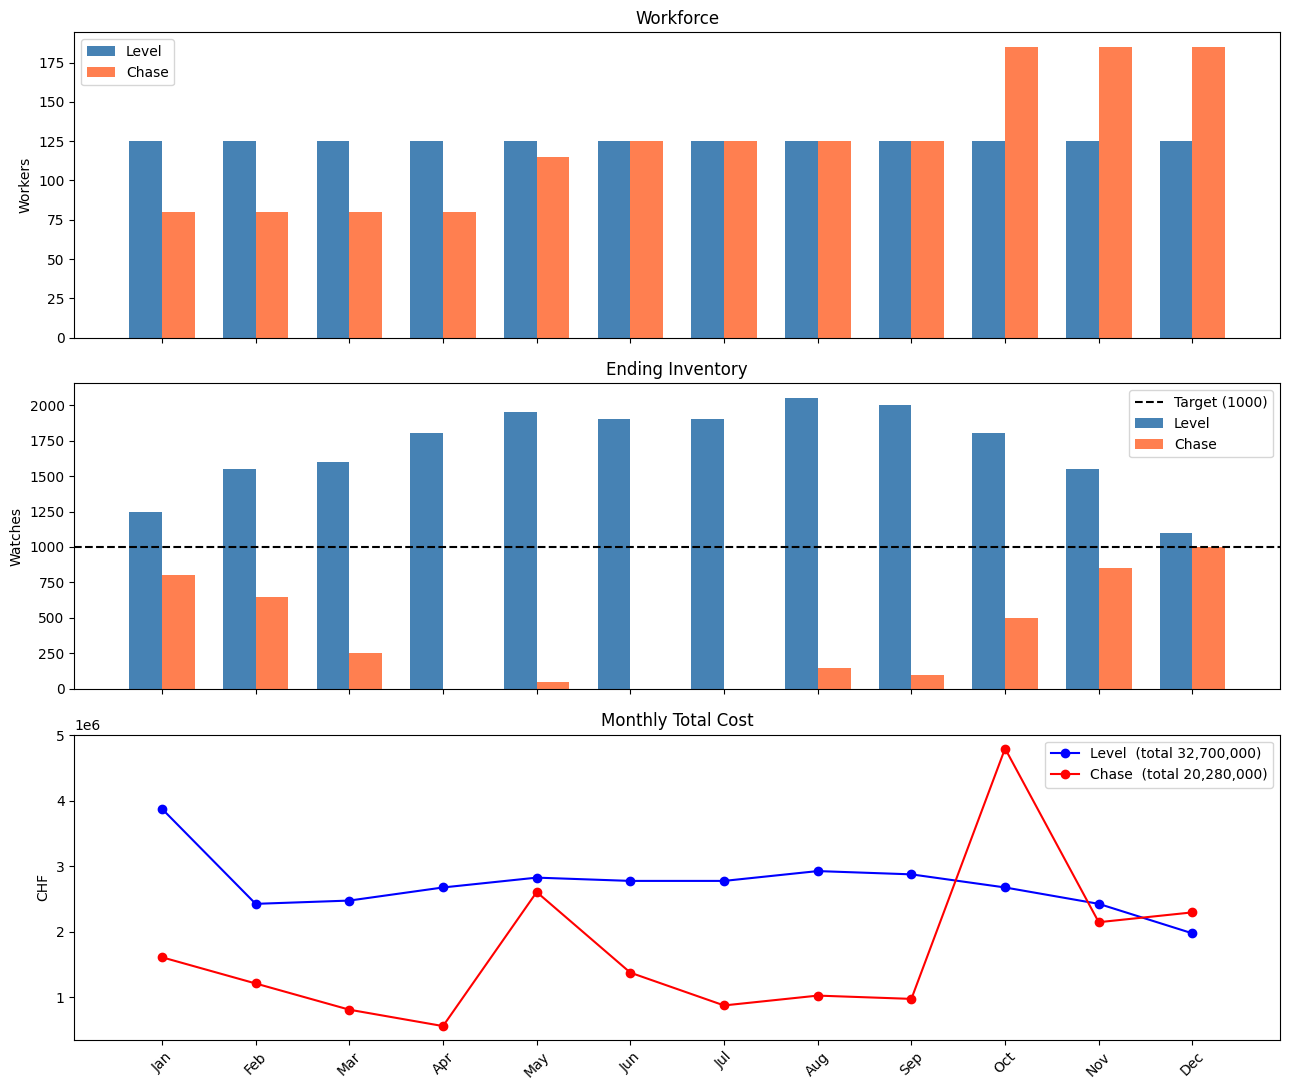

In [6]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model1(strategy="level")
df_chase, s_chase = solve_model1(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 2

In [7]:
# ── Model 2: MILP with overtime (chase / level) ───────────────────────────────

def solve_model2(strategy="level", verbose=False):
    """
    Model 2 – overtime allowed in Mar, May, Sep, Dec (no subcontracting).

    Decision variables:
        W[t]  : workforce at end of month t
        H[t]  : workers hired at start of month t
        F[t]  : workers fired at start of month t
        I[t]  : ending inventory in month t
        OT[t] : overtime production in month t (watches, only in overtime months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model2_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H  = [LpVariable(f"H_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    F  = [LpVariable(f"F_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    I  = [LpVariable(f"I_{t}",  lowBound=0)                for t in range(T)]
    OT = [LpVariable(f"OT_{t}", lowBound=0)                for t in range(T)]

    # ── Overtime cost: 2× regular wage, charged per extra watch produced ──────
    # Regular rate: prod_per_worker watches/worker/month → 1 watch costs wage/prod_per_worker
    # Overtime rate: 2× that
    ot_cost_per_watch = (wage_per_worker * overtime_cost_multiplier) / prod_per_worker

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker  * W[t]  for t in range(T))
      + lpSum(hiring_cost      * H[t]  for t in range(T))
      + lpSum(layoff_cost      * F[t]  for t in range(T))
      + lpSum(holding_cost     * I[t]  for t in range(T))
      + lpSum(ot_cost_per_watch * OT[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]
        month_num = t + 1   # months list is 0-indexed; overtime_months is 1-indexed

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t],  f"workforce_{t}"

        # Inventory balance (regular production + overtime)
        prob += (I[t] == prev_I + prod_per_worker * W[t] + OT[t] - demand_list[t],
                 f"inventory_{t}")

        # Overtime cap: up to overtime_allowance × regular capacity
        prob += OT[t] <= overtime_allowance * prod_per_worker * W[t], f"ot_cap_{t}"

        # Overtime only allowed in designated months
        if month_num not in overtime_months:
            prob += OT[t] == 0, f"ot_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t])))  for t in range(T)]
    hired     = [int(round(value(H[t])))  for t in range(T)]
    fired     = [int(round(value(F[t])))  for t in range(T)]
    overtime  = [value(OT[t])             for t in range(T)]
    inventory = [value(I[t])              for t in range(T)]

    wage_c   = [wage_per_worker   * workers[t]              for t in range(T)]
    hire_c   = [hiring_cost       * hired[t]                for t in range(T)]
    layoff_c = [layoff_cost       * fired[t]                for t in range(T)]
    inv_c    = [holding_cost      * inventory[t]            for t in range(T)]
    ot_c     = [ot_cost_per_watch * overtime[t]             for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [prod_per_worker * w for w in workers],
        "OT Prod.":       [int(round(o)) for o in overtime],
        "Total Prod.":    [prod_per_worker * workers[t] + int(round(overtime[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "OT Cost":        ot_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+ot_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total OT":        sum(ot_c),
        "Total Inventory": sum(inv_c),
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(ot_c)+sum(inv_c),
    }

    return df, summary

In [8]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model2(strategy=strat)
    print(f"\n{'═'*60}")
    print(f"  MODEL 2 – {strat.upper()} STRATEGY")
    print(f"{'═'*60}")
    display(df)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")


════════════════════════════════════════════════════════════
  MODEL 2 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,Inventory Cost,Total Cost
0,Jan,120,30,0,1200,0,1200,900,1200,840000,1500000,0,0,"1,200,000","3,540,000"
1,Feb,120,0,0,1200,0,1200,950,1450,840000,0,0,0,"1,450,000","2,290,000"
2,Mar,120,0,0,1200,0,1200,1200,1450,840000,0,0,0,"1,450,000","2,290,000"
3,Apr,120,0,0,1200,0,1200,1050,1600,840000,0,0,0,"1,600,000","2,440,000"
4,May,120,0,0,1200,20,1220,1100,1720,840000,0,0,"28,000","1,720,000","2,588,000"
5,Jun,120,0,0,1200,0,1200,1300,1620,840000,0,0,0,"1,620,000","2,460,000"
6,Jul,120,0,0,1200,0,1200,1250,1570,840000,0,0,0,"1,570,000","2,410,000"
7,Aug,120,0,0,1200,0,1200,1100,1670,840000,0,0,0,"1,670,000","2,510,000"
8,Sep,120,0,0,1200,240,1440,1300,1810,840000,0,0,"336,000","1,810,000","2,986,000"
9,Oct,120,0,0,1200,0,1200,1450,1560,840000,0,0,0,"1,560,000","2,400,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,080,000
  Total Hiring        :       1,500,000
  Total Layoff        :               0
  Total OT            :         700,000
  Total Inventory     :      17,910,000
  Grand Total         :      30,190,000

════════════════════════════════════════════════════════════
  MODEL 2 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,Inventory Cost,Total Cost
0,Jan,80,0,10,800,0,800,900,800,560000,0,250000,0,"800,000","1,610,000"
1,Feb,80,0,0,800,0,800,950,650,560000,0,0,0,"650,000","1,210,000"
2,Mar,80,0,0,800,0,800,1200,250,560000,0,0,0,"250,000","810,000"
3,Apr,80,0,0,800,0,800,1050,0,560000,0,0,0,-0,"560,000"
4,May,115,35,0,1150,0,1150,1100,50,805000,1750000,0,0,"50,000","2,605,000"
5,Jun,125,10,0,1250,0,1250,1300,0,875000,500000,0,0,-0,"1,375,000"
6,Jul,125,0,0,1250,0,1250,1250,0,875000,0,0,0,-0,"875,000"
7,Aug,125,0,0,1250,0,1250,1100,150,875000,0,0,0,"150,000","1,025,000"
8,Sep,126,1,0,1260,4,1264,1300,114,882000,50000,0,"5,600","114,000","1,051,600"
9,Oct,173,47,0,1730,0,1730,1450,394,1211000,2350000,0,0,"394,000","3,955,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,185,000
  Total Hiring        :       4,650,000
  Total Layoff        :         250,000
  Total OT            :         490,000
  Total Inventory     :       4,032,000
  Grand Total         :      19,607,000


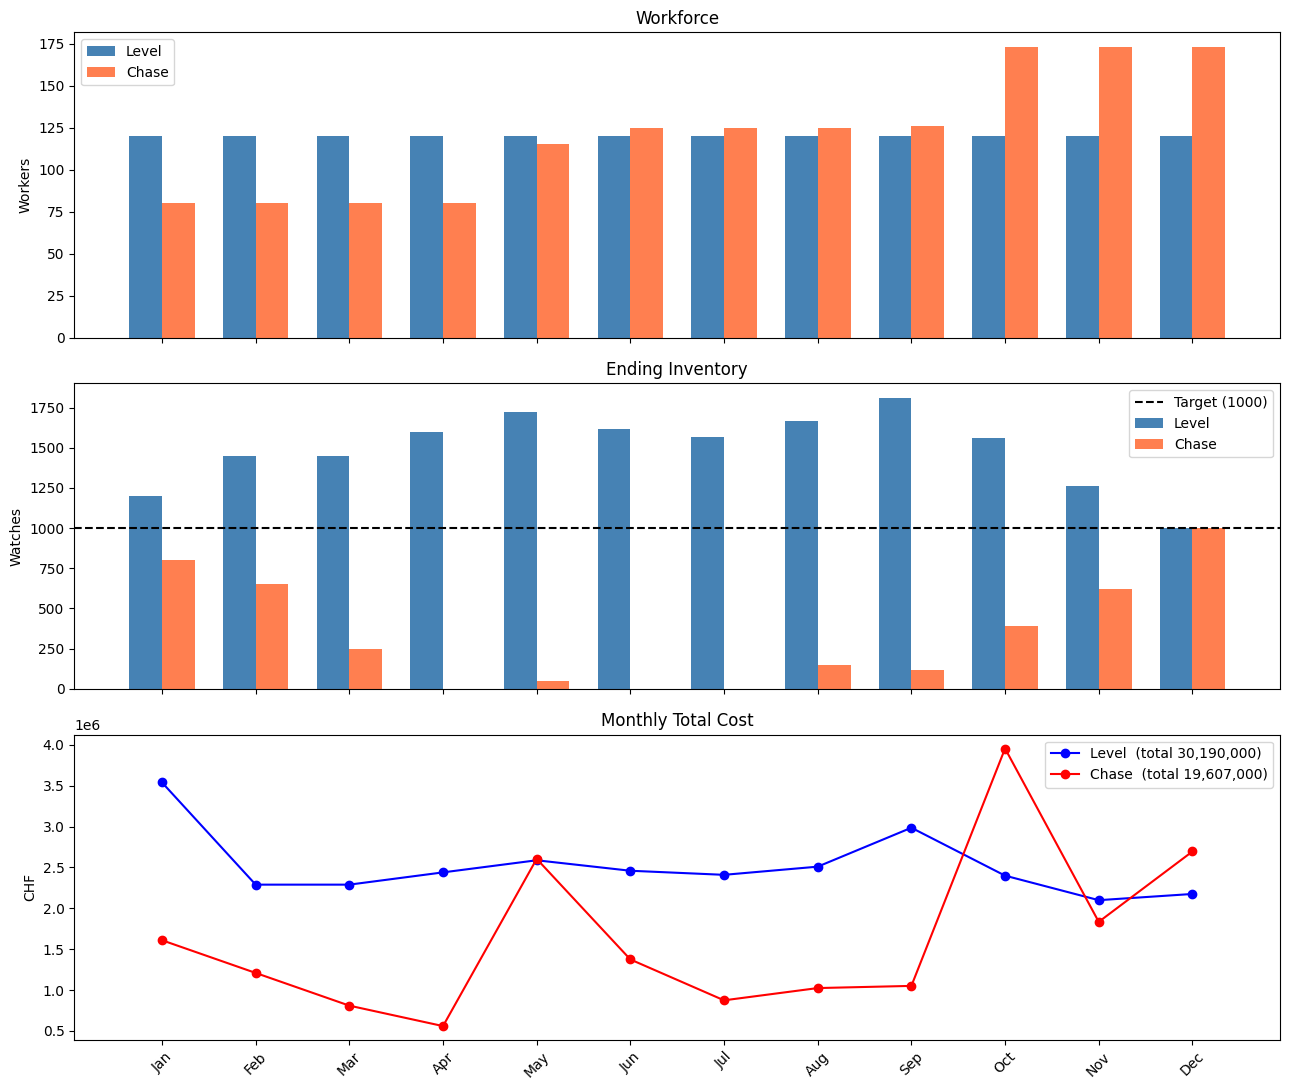

In [9]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model2(strategy="level")
df_chase, s_chase = solve_model2(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 3

In [10]:
# ── Model 3: MILP with subcontracting (chase / level) ────────────────────────

def solve_model3(strategy="level", verbose=False):
    """
    Model 3 – subcontracting allowed in Jun, Jul, Oct, Dec (no overtime).

    Decision variables:
        W[t]  : workforce at end of month t
        H[t]  : workers hired at start of month t
        F[t]  : workers fired at start of month t
        I[t]  : ending inventory in month t
        S[t]  : subcontracted watches in month t (only in subcontracting months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model3_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]
    S = [LpVariable(f"S_{t}", lowBound=0)                for t in range(T)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker    * W[t] for t in range(T))
      + lpSum(hiring_cost        * H[t] for t in range(T))
      + lpSum(layoff_cost        * F[t] for t in range(T))
      + lpSum(holding_cost       * I[t] for t in range(T))
      + lpSum(subcontracting_cost * S[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W   = W0 if t == 0 else W[t-1]
        prev_I   = I0 if t == 0 else I[t-1]
        month_num = t + 1   # subcontracting_months is 1-indexed

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t], f"workforce_{t}"

        # Inventory balance (regular production + subcontracting)
        prob += (I[t] == prev_I + prod_per_worker * W[t] + S[t] - demand_list[t],
                 f"inventory_{t}")

        # Subcontracting cap
        prob += S[t] <= subcontracting_limit, f"sc_cap_{t}"

        # Subcontracting only allowed in designated months
        if month_num not in subcontracting_months:
            prob += S[t] == 0, f"sc_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers      = [int(round(value(W[t]))) for t in range(T)]
    hired        = [int(round(value(H[t]))) for t in range(T)]
    fired        = [int(round(value(F[t]))) for t in range(T)]
    subcontracted = [value(S[t])            for t in range(T)]
    inventory    = [value(I[t])             for t in range(T)]

    wage_c  = [wage_per_worker     * workers[t]       for t in range(T)]
    hire_c  = [hiring_cost         * hired[t]         for t in range(T)]
    layoff_c = [layoff_cost        * fired[t]         for t in range(T)]
    inv_c   = [holding_cost        * inventory[t]     for t in range(T)]
    sc_c    = [subcontracting_cost * subcontracted[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [prod_per_worker * w for w in workers],
        "Subcontracted":  [int(round(s)) for s in subcontracted],
        "Total Prod.":    [prod_per_worker * workers[t] + int(round(subcontracted[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "SC Cost":        sc_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+sc_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":           strategy,
        "Status":             prob.status,
        "Total Wage":         sum(wage_c),
        "Total Hiring":       sum(hire_c),
        "Total Layoff":       sum(layoff_c),
        "Total Subcontracting": sum(sc_c),
        "Total Inventory":    sum(inv_c),
        "Grand Total":        sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(sc_c)+sum(inv_c),
    }

    return df, summary

In [11]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model3(strategy=strat)
    print(f"\n{'═'*60}")
    print(f"  MODEL 3 – {strat.upper()} STRATEGY")
    print(f"{'═'*60}")
    display(df)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")


════════════════════════════════════════════════════════════
  MODEL 3 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,124,34,0,1240,0,1240,900,1240,868000,1700000,0,0,"1,240,000","3,808,000"
1,Feb,124,0,0,1240,0,1240,950,1530,868000,0,0,0,"1,530,000","2,398,000"
2,Mar,124,0,0,1240,0,1240,1200,1570,868000,0,0,0,"1,570,000","2,438,000"
3,Apr,124,0,0,1240,0,1240,1050,1760,868000,0,0,0,"1,760,000","2,628,000"
4,May,124,0,0,1240,0,1240,1100,1900,868000,0,0,0,"1,900,000","2,768,000"
5,Jun,124,0,0,1240,0,1240,1300,1840,868000,0,0,0,"1,840,000","2,708,000"
6,Jul,124,0,0,1240,0,1240,1250,1830,868000,0,0,0,"1,830,000","2,698,000"
7,Aug,124,0,0,1240,0,1240,1100,1970,868000,0,0,0,"1,970,000","2,838,000"
8,Sep,124,0,0,1240,0,1240,1300,1910,868000,0,0,0,"1,910,000","2,778,000"
9,Oct,124,0,0,1240,0,1240,1450,1700,868000,0,0,0,"1,700,000","2,568,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,416,000
  Total Hiring        :       1,700,000
  Total Layoff        :               0
  Total Subcontracting:         300,000
  Total Inventory     :      19,690,000
  Grand Total         :      32,106,000

════════════════════════════════════════════════════════════
  MODEL 3 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,80,0,10,800,0,800,900,800,560000,0,250000,0,"800,000","1,610,000"
1,Feb,80,0,0,800,0,800,950,650,560000,0,0,0,"650,000","1,210,000"
2,Mar,80,0,0,800,0,800,1200,250,560000,0,0,0,"250,000","810,000"
3,Apr,80,0,0,800,0,800,1050,0,560000,0,0,0,-0,"560,000"
4,May,115,35,0,1150,0,1150,1100,50,805000,1750000,0,0,"50,000","2,605,000"
5,Jun,125,10,0,1250,0,1250,1300,0,875000,500000,0,0,-0,"1,375,000"
6,Jul,125,0,0,1250,0,1250,1250,0,875000,0,0,0,-0,"875,000"
7,Aug,125,0,0,1250,0,1250,1100,150,875000,0,0,0,"150,000","1,025,000"
8,Sep,125,0,0,1250,0,1250,1300,100,875000,0,0,0,"100,000","975,000"
9,Oct,185,60,0,1850,0,1850,1450,500,1295000,3000000,0,0,"500,000","4,795,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,430,000
  Total Hiring        :       5,250,000
  Total Layoff        :         250,000
  Total Subcontracting:               0
  Total Inventory     :       4,350,000
  Grand Total         :      20,280,000


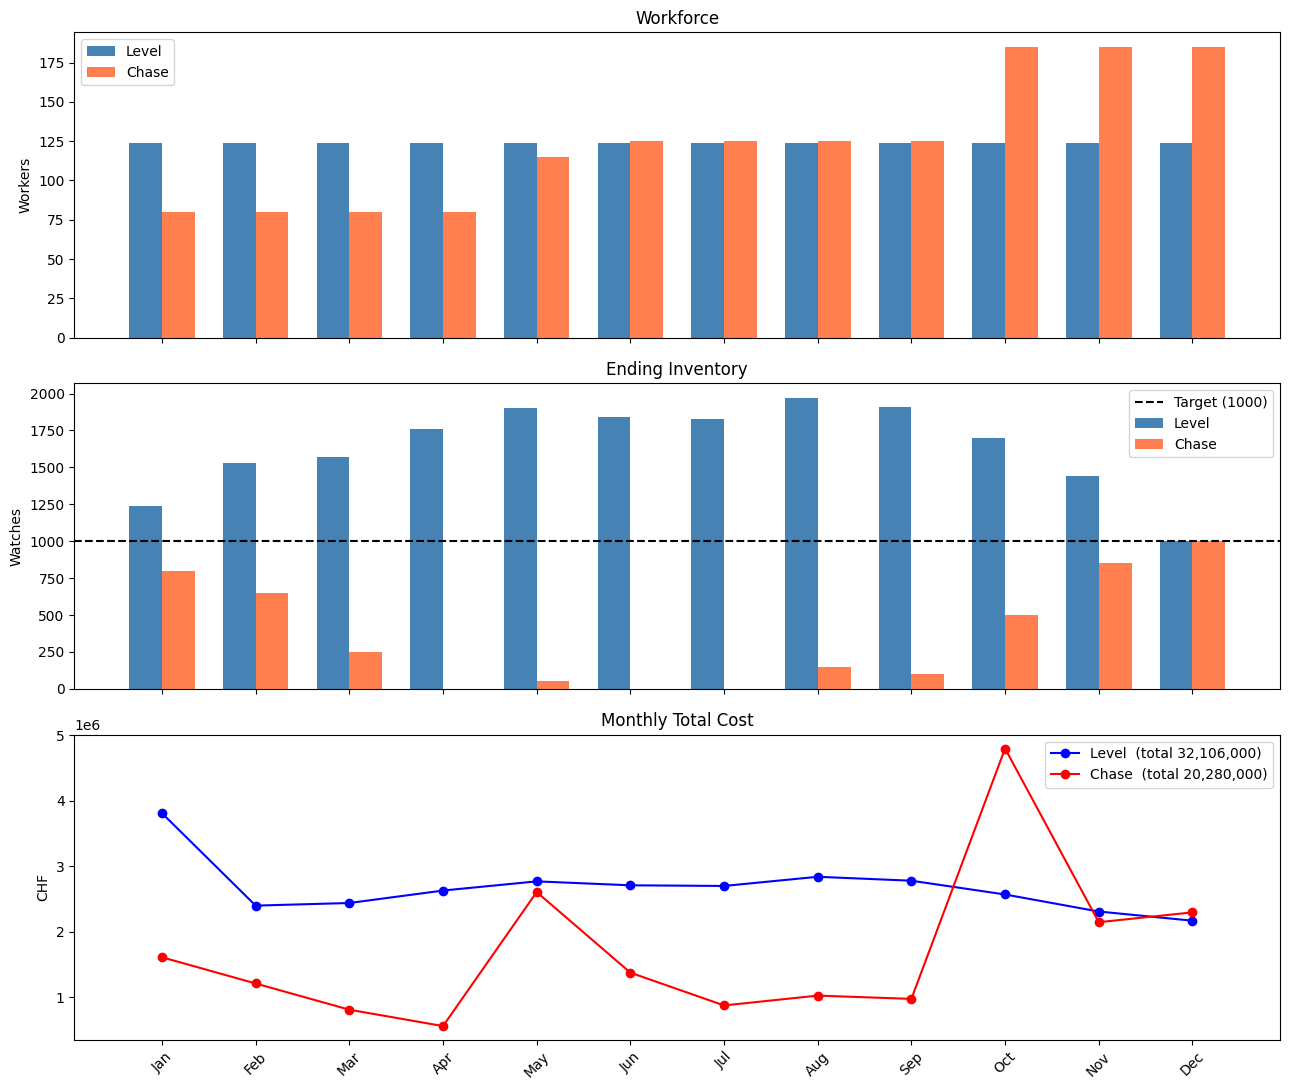

In [12]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model3(strategy="level")
df_chase, s_chase = solve_model3(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 4


In [13]:
# ── Model 4: MILP with overtime + subcontracting (chase / level) ──────────────

def solve_model4(strategy="level", verbose=False):
    """
    Model 4 – overtime (Mar, May, Sep, Dec) + subcontracting (Jun, Jul, Oct, Dec).

    Decision variables:
        W[t]  : workforce at end of month t
        H[t]  : workers hired at start of month t
        F[t]  : workers fired at start of month t
        I[t]  : ending inventory in month t
        OT[t] : overtime production in month t (only in overtime months)
        S[t]  : subcontracted watches in month t (only in subcontracting months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model4_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H  = [LpVariable(f"H_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    F  = [LpVariable(f"F_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    I  = [LpVariable(f"I_{t}",  lowBound=0)                for t in range(T)]
    OT = [LpVariable(f"OT_{t}", lowBound=0)                for t in range(T)]
    S  = [LpVariable(f"S_{t}",  lowBound=0)                for t in range(T)]

    # Overtime cost per watch produced
    ot_cost_per_watch = (wage_per_worker * overtime_cost_multiplier) / prod_per_worker

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker     * W[t]  for t in range(T))
      + lpSum(hiring_cost         * H[t]  for t in range(T))
      + lpSum(layoff_cost         * F[t]  for t in range(T))
      + lpSum(holding_cost        * I[t]  for t in range(T))
      + lpSum(ot_cost_per_watch   * OT[t] for t in range(T))
      + lpSum(subcontracting_cost * S[t]  for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W    = W0 if t == 0 else W[t-1]
        prev_I    = I0 if t == 0 else I[t-1]
        month_num = t + 1

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t], f"workforce_{t}"

        # Inventory balance (regular + overtime + subcontracting)
        prob += (I[t] == prev_I + prod_per_worker * W[t] + OT[t] + S[t] - demand_list[t],
                 f"inventory_{t}")

        # Overtime cap: up to overtime_allowance × regular capacity
        prob += OT[t] <= overtime_allowance * prod_per_worker * W[t], f"ot_cap_{t}"

        # Subcontracting cap
        prob += S[t] <= subcontracting_limit, f"sc_cap_{t}"

        # Overtime only in designated months
        if month_num not in overtime_months:
            prob += OT[t] == 0, f"ot_forbidden_{t}"

        # Subcontracting only in designated months
        if month_num not in subcontracting_months:
            prob += S[t] == 0, f"sc_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers       = [int(round(value(W[t])))  for t in range(T)]
    hired         = [int(round(value(H[t])))  for t in range(T)]
    fired         = [int(round(value(F[t])))  for t in range(T)]
    overtime      = [value(OT[t])             for t in range(T)]
    subcontracted = [value(S[t])              for t in range(T)]
    inventory     = [value(I[t])              for t in range(T)]

    wage_c    = [wage_per_worker     * workers[t]       for t in range(T)]
    hire_c    = [hiring_cost         * hired[t]         for t in range(T)]
    layoff_c  = [layoff_cost         * fired[t]         for t in range(T)]
    inv_c     = [holding_cost        * inventory[t]     for t in range(T)]
    ot_c      = [ot_cost_per_watch   * overtime[t]      for t in range(T)]
    sc_c      = [subcontracting_cost * subcontracted[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [prod_per_worker * w for w in workers],
        "OT Prod.":       [int(round(o)) for o in overtime],
        "Subcontracted":  [int(round(s)) for s in subcontracted],
        "Total Prod.":    [prod_per_worker * workers[t] + int(round(overtime[t])) + int(round(subcontracted[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "OT Cost":        ot_c,
        "SC Cost":        sc_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+ot_c[t]+sc_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":             strategy,
        "Status":               prob.status,
        "Total Wage":           sum(wage_c),
        "Total Hiring":         sum(hire_c),
        "Total Layoff":         sum(layoff_c),
        "Total OT":             sum(ot_c),
        "Total Subcontracting": sum(sc_c),
        "Total Inventory":      sum(inv_c),
        "Grand Total":          sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(ot_c)+sum(sc_c)+sum(inv_c),
    }

    return df, summary

In [14]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model4(strategy=strat)
    print(f"\n{'\u2550'*60}")
    print(f"  MODEL 4 \u2013 {strat.upper()} STRATEGY")
    print(f"{'\u2550'*60}")
    display(df)
    print(f"\n\u2500\u2500 Cost Summary (CHF) \u2500\u2500")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")



════════════════════════════════════════════════════════════
  MODEL 4 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,120,30,0,1200,0,0,1200,900,1200,840000,1500000,0,0,0,"1,200,000","3,540,000"
1,Feb,120,0,0,1200,0,0,1200,950,1450,840000,0,0,0,0,"1,450,000","2,290,000"
2,Mar,120,0,0,1200,0,0,1200,1200,1450,840000,0,0,0,0,"1,450,000","2,290,000"
3,Apr,120,0,0,1200,0,0,1200,1050,1600,840000,0,0,0,0,"1,600,000","2,440,000"
4,May,120,0,0,1200,20,0,1220,1100,1720,840000,0,0,"28,000",0,"1,720,000","2,588,000"
5,Jun,120,0,0,1200,0,0,1200,1300,1620,840000,0,0,0,0,"1,620,000","2,460,000"
6,Jul,120,0,0,1200,0,0,1200,1250,1570,840000,0,0,0,0,"1,570,000","2,410,000"
7,Aug,120,0,0,1200,0,0,1200,1100,1670,840000,0,0,0,0,"1,670,000","2,510,000"
8,Sep,120,0,0,1200,240,0,1440,1300,1810,840000,0,0,"336,000",0,"1,810,000","2,986,000"
9,Oct,120,0,0,1200,0,0,1200,1450,1560,840000,0,0,0,0,"1,560,000","2,400,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,080,000
  Total Hiring        :       1,500,000
  Total Layoff        :               0
  Total OT            :         700,000
  Total Subcontracting:               0
  Total Inventory     :      17,910,000
  Grand Total         :      30,190,000

════════════════════════════════════════════════════════════
  MODEL 4 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,80,0,10,800,0,0,800,900,800,560000,0,250000,0,0,"800,000","1,610,000"
1,Feb,80,0,0,800,0,0,800,950,650,560000,0,0,0,0,"650,000","1,210,000"
2,Mar,80,0,0,800,0,0,800,1200,250,560000,0,0,0,0,"250,000","810,000"
3,Apr,80,0,0,800,0,0,800,1050,0,560000,0,0,0,0,-0,"560,000"
4,May,115,35,0,1150,0,0,1150,1100,50,805000,1750000,0,0,0,"50,000","2,605,000"
5,Jun,125,10,0,1250,0,0,1250,1300,0,875000,500000,0,0,0,-0,"1,375,000"
6,Jul,125,0,0,1250,0,0,1250,1250,0,875000,0,0,0,0,-0,"875,000"
7,Aug,125,0,0,1250,0,0,1250,1100,150,875000,0,0,0,0,"150,000","1,025,000"
8,Sep,126,1,0,1260,4,0,1264,1300,114,882000,50000,0,"5,600",0,"114,000","1,051,600"
9,Oct,173,47,0,1730,0,0,1730,1450,394,1211000,2350000,0,0,0,"394,000","3,955,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,185,000
  Total Hiring        :       4,650,000
  Total Layoff        :         250,000
  Total OT            :         490,000
  Total Subcontracting:               0
  Total Inventory     :       4,032,000
  Grand Total         :      19,607,000


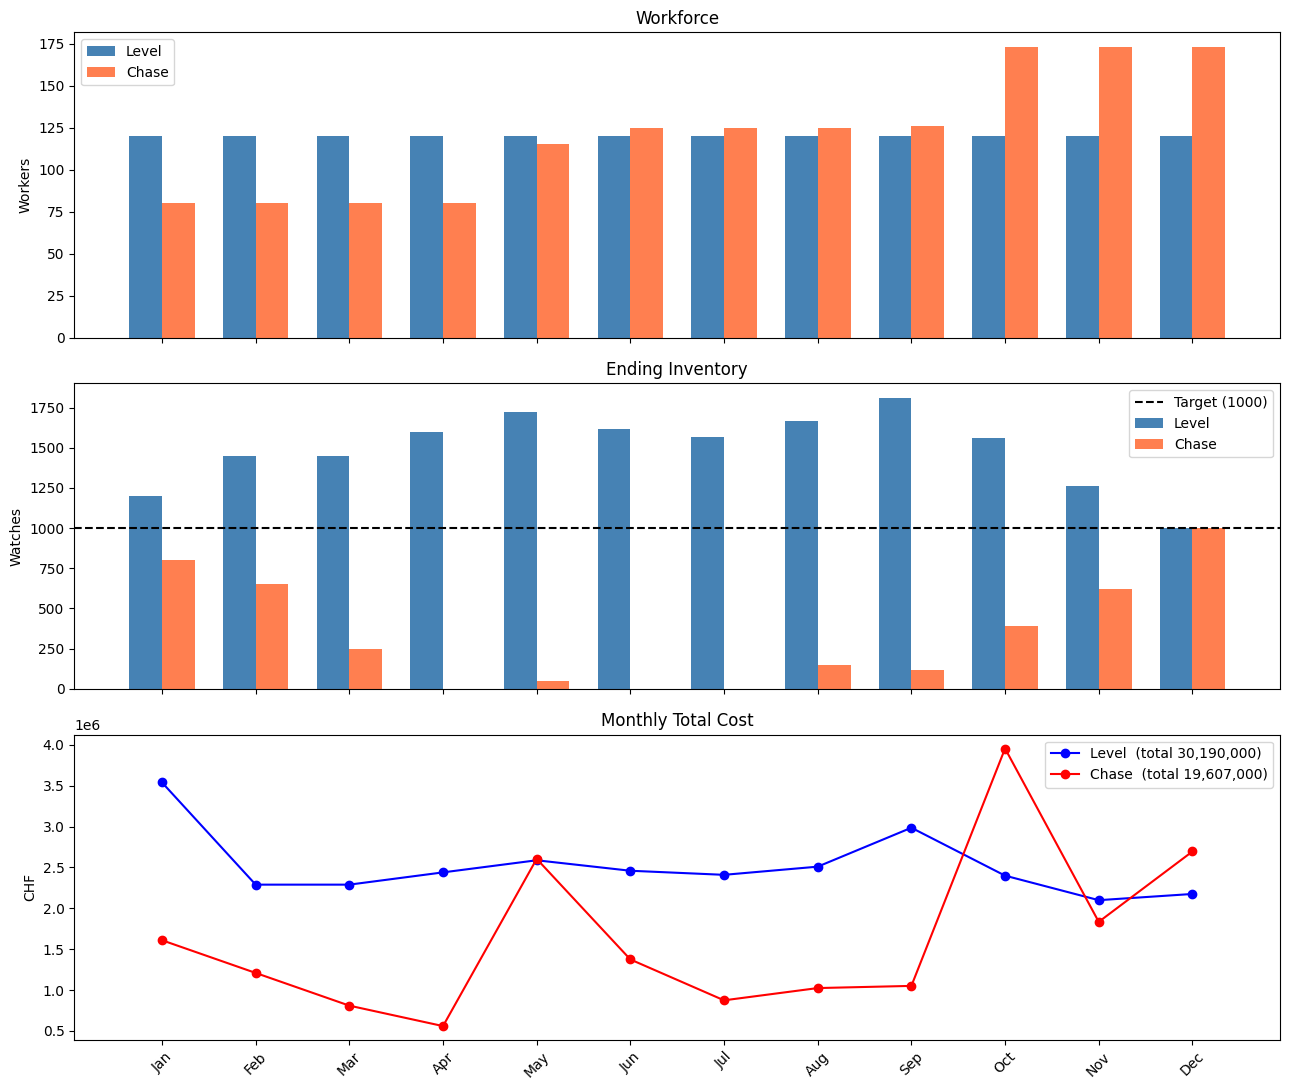

In [15]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model4(strategy="level")
df_chase, s_chase = solve_model4(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

## Graphs

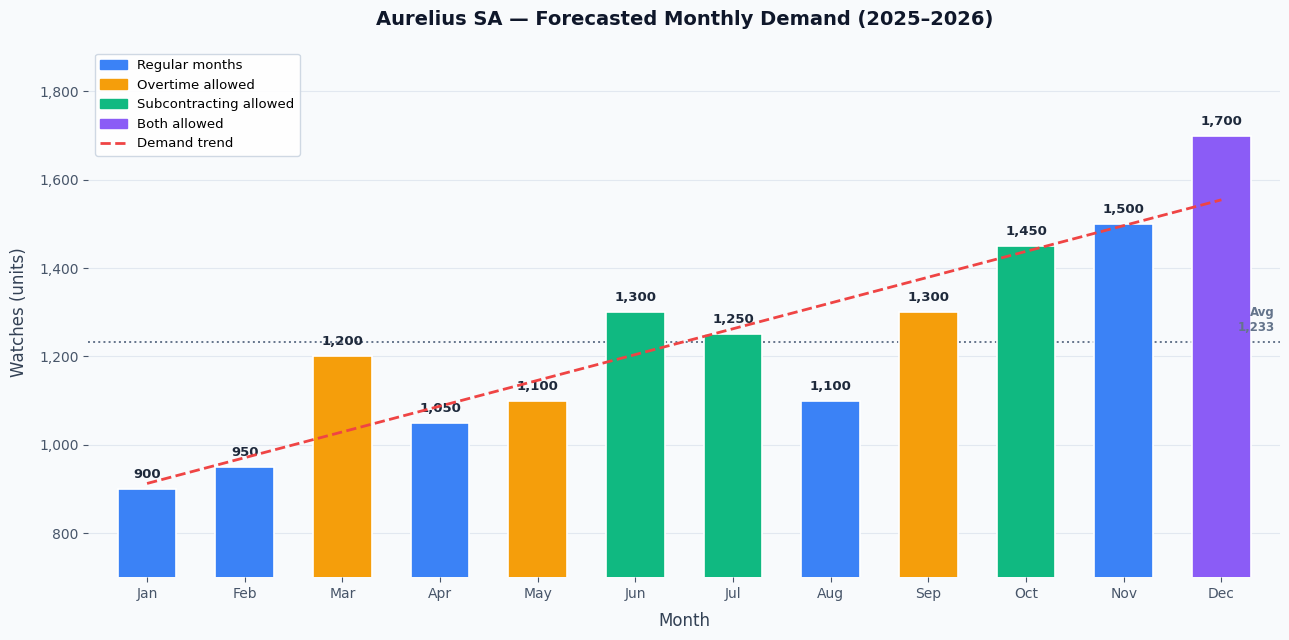

In [16]:
# ── Forecasted Monthly Demand Chart ──────────────────────────────────────────

# Overtime and subcontracting months (1-indexed)
overtime_months_set      = {3, 5, 9, 12}   # Mar, May, Sep, Dec
subcontracting_months_set = {6, 7, 10, 12} # Jun, Jul, Oct, Dec

# Color each bar
colors = []
for i in range(1, 13):
    if i in overtime_months_set and i in subcontracting_months_set:
        colors.append("#8B5CF6")   # purple = both
    elif i in overtime_months_set:
        colors.append("#F59E0B")   # amber = overtime
    elif i in subcontracting_months_set:
        colors.append("#10B981")   # green = subcontracting
    else:
        colors.append("#3B82F6")   # blue = regular

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# Bars
bars = ax.bar(MONTH_NAMES, demand_list, color=colors, width=0.6,
              edgecolor="white", linewidth=1.2, zorder=3)

# Trend line
x_num = np.arange(len(MONTH_NAMES))
z = np.polyfit(x_num, demand_list, 1)
p = np.poly1d(z)
ax.plot(MONTH_NAMES, p(x_num), color="#EF4444", linewidth=2,
        linestyle="--", zorder=4, label="Trend")

# Value labels on bars
for bar, val in zip(bars, demand_list):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 18,
            f"{val:,}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", color="#1E293B")

# Reference line: average demand
avg = sum(demand_list) / len(demand_list)
ax.axhline(avg, color="#64748B", linewidth=1.4, linestyle=":", zorder=2)
ax.text(11.55, avg + 18, f"Avg\n{avg:,.0f}",
        ha="right", va="bottom", fontsize=8.5,
        color="#64748B", fontweight="bold")

# Axes styling
ax.set_ylim(700, 1900)
ax.set_xlim(-0.6, 11.6)
ax.set_xlabel("Month", fontsize=12, color="#334155", labelpad=8)
ax.set_ylabel("Watches (units)", fontsize=12, color="#334155", labelpad=8)
ax.set_title("Aurelius SA — Forecasted Monthly Demand (2025–2026)",
             fontsize=14, fontweight="bold", color="#0F172A", pad=16)

ax.tick_params(colors="#475569", labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Legend
legend_items = [
    mpatches.Patch(color="#3B82F6", label="Regular months"),
    mpatches.Patch(color="#F59E0B", label="Overtime allowed"),
    mpatches.Patch(color="#10B981", label="Subcontracting allowed"),
    mpatches.Patch(color="#8B5CF6", label="Both allowed"),
    plt.Line2D([0], [0], color="#EF4444", linewidth=2,
               linestyle="--", label="Demand trend"),
]
ax.legend(handles=legend_items, loc="upper left",
          frameon=True, framealpha=0.9, fontsize=9.5,
          edgecolor="#CBD5E1")

plt.tight_layout()
plt.show()

## Cross-Model Comparison



=== Grand Total Cost Comparison (CHF) ===


,Model 1 (Base),Model 2 (+OT),Model 3 (+SC),Model 4 (OT+SC)
Strategy,,,,
level,"32,700,000","30,190,000","32,106,000","30,190,000"
chase,"20,280,000","19,607,000","20,280,000","19,607,000"


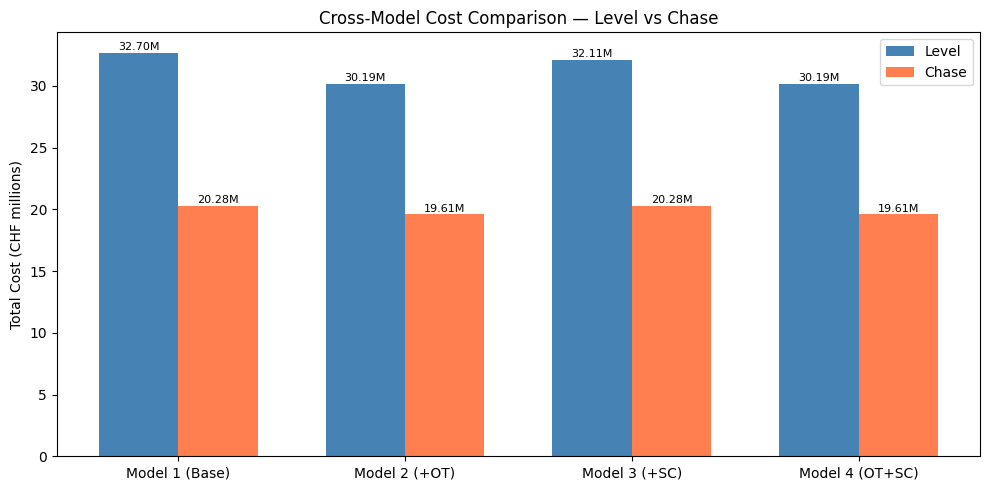

In [17]:
# ── Collect results from all 4 models (both strategies) and compare ──────────

model_results = {}
for strat in ("level", "chase"):
    _, s1 = solve_model1(strategy=strat)
    _, s2 = solve_model2(strategy=strat)
    _, s3 = solve_model3(strategy=strat)
    _, s4 = solve_model4(strategy=strat)
    model_results[strat] = {
        "Model 1 (Base)":        s1["Grand Total"],
        "Model 2 (+OT)":         s2["Grand Total"],
        "Model 3 (+SC)":         s3["Grand Total"],
        "Model 4 (OT+SC)":       s4["Grand Total"],
    }

df_comp = pd.DataFrame(model_results).T
df_comp.index.name = "Strategy"
print("\n=== Grand Total Cost Comparison (CHF) ===")
display(df_comp.style.format("{:,.0f}"))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.35
labels = list(model_results["level"].keys())
level_vals = list(model_results["level"].values())
chase_vals = list(model_results["chase"].values())

bars1 = ax.bar(x - w/2, [v/1e6 for v in level_vals], w, color="steelblue", label="Level")
bars2 = ax.bar(x + w/2, [v/1e6 for v in chase_vals],  w, color="coral",     label="Chase")

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}M", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Total Cost (CHF millions)")
ax.set_title("Cross-Model Cost Comparison — Level vs Chase")
ax.legend()
plt.tight_layout()
plt.show()


## Inventory Management


In [18]:
# ── Inventory Management Parameters ──────────────────────────────────────────
# Component data from Table 3 (slide 17/20)
# holding_cost_per_unit_month: CHF/unit/month  |  ordering_cost: CHF per order
# lead_time_days              |  shelf_life_days

from scipy.stats import norm

SERVICE_LEVEL = 0.98
Z = norm.ppf(SERVICE_LEVEL)           # ≈ 2.054 for 98%
WORKING_DAYS  = 365                   # days per year used for annualisation

print(f"Service level : {SERVICE_LEVEL:.0%}")
print(f"z-score (z_{SERVICE_LEVEL:.0%}): {Z:.4f}")


Service level : 98%
z-score (z_98%): 2.0537


In [19]:
# ── EOQ & Reorder Point Calculations ─────────────────────────────────────────
# For each component we derive:
#   μ_d , σ_d   : mean and std-dev of DAILY demand (from Demand_data.csv)
#   μ_annual    : annualised mean demand (μ_d × 365)
#   h_annual    : annual holding cost   (h_monthly × 12)
#   EOQ         : Economic Order Quantity = sqrt(2 K μ_annual / h_annual)
#   μ_L, σ_L    : mean and std-dev of demand during lead time L
#   Safety Stock: z × σ_L
#   R           : Reorder point = μ_L + Safety Stock
#   Cycle Time  : EOQ / μ_d  (days to consume one order)

inv_records = []

for comp_name, params in components.items():
    series    = demand_df[comp_name]          # daily demand series
    mu_d      = series.mean()
    sigma_d   = series.std(ddof=1)

    mu_annual = mu_d * WORKING_DAYS
    h_annual  = params["holding_cost_per_unit_month"] * 12   # monthly → annual
    K         = params["ordering_cost"]
    L         = params["lead_time_days"]

    # EOQ
    EOQ = np.sqrt(2 * K * mu_annual / h_annual)

    # Lead-time demand statistics
    mu_L    = mu_d * L
    sigma_L = sigma_d * np.sqrt(L)

    # Safety stock & reorder point
    SS = Z * sigma_L
    R  = mu_L + SS

    # Cycle time (days)
    cycle_days = EOQ / mu_d

    # Annual total relevant cost  (ordering + holding cycle stock + holding SS)
    n_orders   = mu_annual / EOQ
    avg_inv    = EOQ / 2 + SS
    ann_cost   = n_orders * K + avg_inv * h_annual

    # Shelf-life check
    shelf_ok = "✓" if cycle_days < params["shelf_life_days"] else "⚠ PERISHABILITY RISK"

    inv_records.append({
        "Component":          comp_name,
        "μ_daily":            round(mu_d,   3),
        "σ_daily":            round(sigma_d,3),
        "Lead Time (days)":   L,
        "EOQ":                round(EOQ,    1),
        "Safety Stock":       round(SS,     1),
        "Reorder Point (R)":  round(R,      1),
        "Cycle Time (days)":  round(cycle_days, 1),
        "Shelf Life (days)":  params["shelf_life_days"],
        "Shelf Check":        shelf_ok,
        "Ann. Cost (CHF)":    round(ann_cost, 0),
        # proxy for ABC: annual demand × monthly holding cost
        "_abc_value":         mu_annual * params["holding_cost_per_unit_month"],
    })

df_inv = pd.DataFrame(inv_records)

print("=== EOQ & Reorder Points ===")
display(df_inv.drop(columns=["_abc_value"]).style
        .format({
            "μ_daily": "{:.3f}", "σ_daily": "{:.3f}",
            "EOQ": "{:.1f}", "Safety Stock": "{:.1f}",
            "Reorder Point (R)": "{:.1f}", "Cycle Time (days)": "{:.1f}",
            "Ann. Cost (CHF)": "{:,.0f}",
        }))


=== EOQ & Reorder Points ===


,Component,μ_daily,σ_daily,Lead Time (days),EOQ,Safety Stock,Reorder Point (R),Cycle Time (days),Shelf Life (days),Shelf Check,Ann. Cost (CHF)
0,3235 Movement,14.260,3.561,60,80.7,56.7,912.3,5.7,365,✓,"1,977,317"
1,Oystersteel Case,15.178,4.281,45,127.1,59.0,742.0,8.4,505,✓,"893,263"
2,Sapphire Crystal,14.211,3.588,30,131.5,40.4,466.7,9.3,365,✓,"412,432"
3,Jubilee Bracelet,8.016,0.994,35,88.1,12.1,292.7,11.0,1460,✓,"264,430"
4,Lubricant Oil,150.723,41.180,14,428.2,316.4,2426.6,2.8,730,✓,"446,804"
5,Diamond Marker,47.805,5.094,21,139.2,47.9,1051.9,2.9,1825,✓,"2,021,560"
6,Gold Crown,8.005,3.033,40,83.4,39.4,359.6,10.4,730,✓,"515,770"


In [20]:
# ── ABC Classification ────────────────────────────────────────────────────────
# Proxy: annual_value = μ_annual × holding_cost_per_unit_month
# (unit purchase prices are not provided; holding cost is used as a value proxy)

df_abc = df_inv[["Component","_abc_value","EOQ","Reorder Point (R)","Ann. Cost (CHF)"]].copy()
df_abc = df_abc.sort_values("_abc_value", ascending=False).reset_index(drop=True)
df_abc["Ann. Value Proxy"] = df_abc["_abc_value"].round(0)
total_val = df_abc["_abc_value"].sum()
df_abc["Cumulative %"]     = (df_abc["_abc_value"].cumsum() / total_val * 100).round(1)
df_abc["ABC Class"]        = df_abc["Cumulative %"].apply(
    lambda x: "A" if x <= 70 else ("B" if x <= 90 else "C"))
df_abc = df_abc.drop(columns=["_abc_value"])

print("=== ABC Classification (value proxy = μ_annual × h_monthly) ===")
display(df_abc.style.format({"Ann. Value Proxy": "{:,.0f}",
                              "EOQ": "{:.1f}",
                              "Reorder Point (R)": "{:.1f}",
                              "Ann. Cost (CHF)": "{:,.0f}",
                              "Cumulative %": "{:.1f}%"})
        .apply(lambda col: [
            "background-color: #fde68a" if v=="A"
            else "background-color: #bbf7d0" if v=="B"
            else "background-color: #e0e7ff" if v=="C"
            else "" for v in col], subset=["ABC Class"]))


=== ABC Classification (value proxy = μ_annual × h_monthly) ===


,Component,EOQ,Reorder Point (R),Ann. Cost (CHF),Ann. Value Proxy,Cumulative %,ABC Class
0,Diamond Marker,139.2,1051.9,"2,021,560","15,704,100",53.0%,A
1,3235 Movement,80.7,912.3,"1,977,317","6,246,000",74.1%,B
2,Lubricant Oil,428.2,2426.6,"446,804","2,750,700",83.4%,B
3,Oystersteel Case,127.1,742.0,"893,263","2,216,000",90.9%,C
4,Sapphire Crystal,131.5,466.7,"412,432","1,037,400",94.4%,C
5,Gold Crown,83.4,359.6,"515,770","1,022,700",97.8%,C
6,Jubilee Bracelet,88.1,292.7,"264,430","643,720",100.0%,C


In [21]:
# ── Inventory Policy Recommendation ─────────────────────────────────────────
# Based on ABC class, lead time and demand variability, we assign policies:
#   A / high lead-time → (Q,R) Continuous Review (monitor closely)
#   B                  → (Q,R) Continuous Review (standard)
#   C / low variability→ (P,T) Periodic Review (simpler to operate)

policy_notes = {
    "3235 Movement":    ("(Q,R) Continuous",  "B", "Long 60-day LT; high unit value → monitor continuously"),
    "Oystersteel Case": ("(P,T) Periodic",    "C", "Internal supplier; moderate LT → periodic review feasible"),
    "Sapphire Crystal": ("(P,T) Periodic",    "C", "Internal supplier; low variability → periodic review"),
    "Jubilee Bracelet": ("(P,T) Periodic",    "C", "Very low σ_d (≈1); minimal safety stock needed"),
    "Lubricant Oil":    ("(Q,R) Continuous",  "B", "High volume (150 g/day); large safety stock → watch closely"),
    "Diamond Marker":   ("(Q,R) Continuous",  "A", "Highest value proxy; only A-item → top priority"),
    "Gold Crown":       ("(P,T) Periodic",    "C", "Moderate cost; Supplier CH → bundle with Diamond Marker orders"),
}

rows = []
for comp, (policy, abc, rationale) in policy_notes.items():
    rec = df_inv[df_inv["Component"] == comp].iloc[0]
    rows.append({
        "Component":         comp,
        "ABC":               abc,
        "Recommended Policy":policy,
        "EOQ":               rec["EOQ"],
        "Reorder Point (R)": rec["Reorder Point (R)"],
        "Safety Stock":      rec["Safety Stock"],
        "Rationale":         rationale,
    })

df_policy = pd.DataFrame(rows)
print("=== Final Inventory Policy Recommendations ===")
display(df_policy.style.format({"EOQ":"{:.1f}","Reorder Point (R)":"{:.1f}","Safety Stock":"{:.1f}"}))


=== Final Inventory Policy Recommendations ===


,Component,ABC,Recommended Policy,EOQ,Reorder Point (R),Safety Stock,Rationale
0,3235 Movement,B,"(Q,R) Continuous",80.7,912.3,56.7,Long 60-day LT; high unit value → monitor continuously
1,Oystersteel Case,C,"(P,T) Periodic",127.1,742.0,59.0,Internal supplier; moderate LT → periodic review feasible
2,Sapphire Crystal,C,"(P,T) Periodic",131.5,466.7,40.4,Internal supplier; low variability → periodic review
3,Jubilee Bracelet,C,"(P,T) Periodic",88.1,292.7,12.1,Very low σ_d (≈1); minimal safety stock needed
4,Lubricant Oil,B,"(Q,R) Continuous",428.2,2426.6,316.4,High volume (150 g/day); large safety stock → watch closely
5,Diamond Marker,A,"(Q,R) Continuous",139.2,1051.9,47.9,Highest value proxy; only A-item → top priority
6,Gold Crown,C,"(P,T) Periodic",83.4,359.6,39.4,Moderate cost; Supplier CH → bundle with Diamond Marker orders


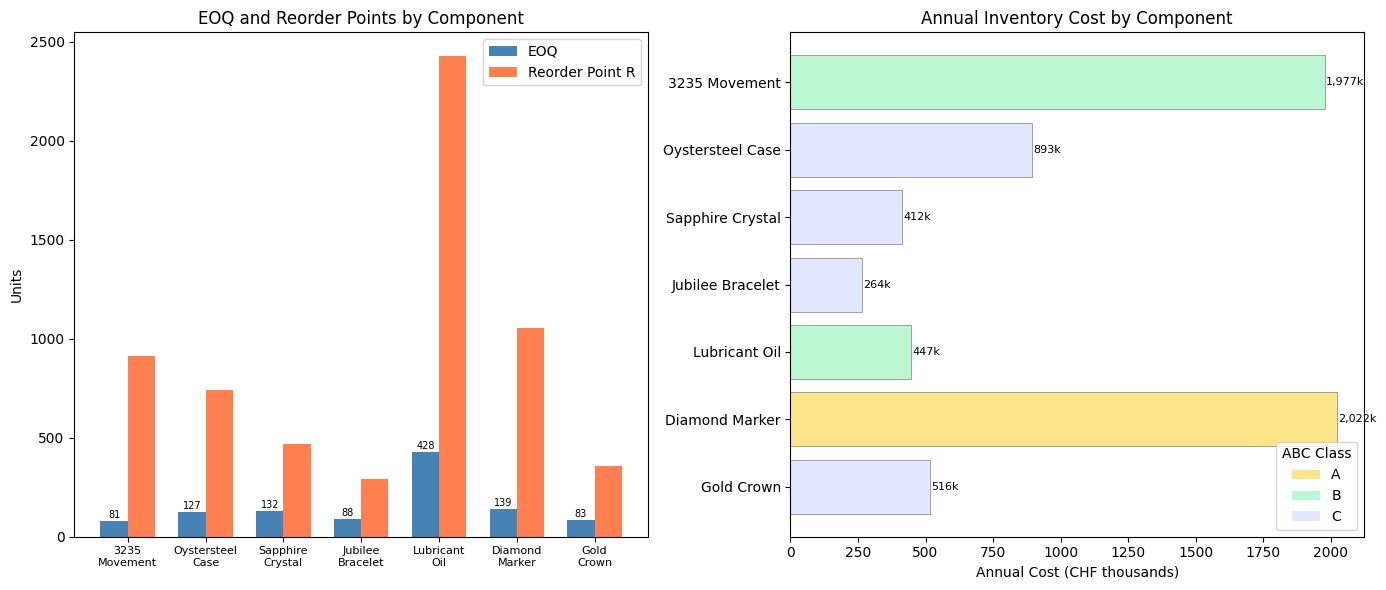

In [22]:
# ── Inventory Visualisation ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: EOQ and Reorder Points by component ────────────────────────────────
comp_labels = [c.replace(" ", "\n") for c in df_inv["Component"]]
x = np.arange(len(comp_labels))
w = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, df_inv["EOQ"],               width=w, color="steelblue", label="EOQ")
b2 = ax.bar(x + w/2, df_inv["Reorder Point (R)"], width=w, color="coral",     label="Reorder Point R")
ax.set_xticks(x); ax.set_xticklabels(comp_labels, fontsize=8)
ax.set_ylabel("Units"); ax.set_title("EOQ and Reorder Points by Component")
ax.legend()

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=7)

# ── Right: Annual cost breakdown ──────────────────────────────────────────────
ax2 = axes[1]
colors_abc = {"A":"#fde68a","B":"#bbf7d0","C":"#e0e7ff"}
abc_map = dict(zip(df_policy["Component"], df_policy["ABC"]))
bar_colors = [colors_abc[abc_map[c]] for c in df_inv["Component"]]

bars = ax2.barh(df_inv["Component"], df_inv["Ann. Cost (CHF)"] / 1e3,
                color=bar_colors, edgecolor="grey", linewidth=0.5)
ax2.set_xlabel("Annual Cost (CHF thousands)")
ax2.set_title("Annual Inventory Cost by Component")
ax2.invert_yaxis()
for bar, val in zip(bars, df_inv["Ann. Cost (CHF)"]):
    ax2.text(bar.get_width() + 5, bar.get_y()+bar.get_height()/2,
             f"{val/1e3:,.0f}k", va="center", fontsize=8)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#fde68a", label="A"),
              Patch(facecolor="#bbf7d0", label="B"),
              Patch(facecolor="#e0e7ff", label="C")]
ax2.legend(handles=legend_els, title="ABC Class", loc="lower right")

plt.tight_layout()
plt.show()
